## GNN de precio de alquiler (prueba rápida)

Solo entrena y evalúa `RentalPriceGNN` usando el grafo k-NN construido con la distancia entre departamentos.


In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import BallTree
import matplotlib.pyplot as plt
import geopandas as gpd

PROJECT_ROOT = Path('..').resolve()
import sys
sys.path.append(str(PROJECT_ROOT))
print('PROJECT_ROOT', PROJECT_ROOT)

from ml_core.models import RentalPriceGNN

print('torch.cuda.is_available ->', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name())


PROJECT_ROOT /home/saneliges/Escritorio/PredictorPrecioMetroCuadradoAlquileres
torch.cuda.is_available -> True
GPU: NVIDIA GeForce RTX 3060


In [2]:
# Cargar datos procesados de venta
# El dataset ya incluye `log_precio` y columnas numéricas útiles.
data_path = PROJECT_ROOT / 'scraper_service' / 'storage' / 'data' / 'arg_venta_caba_processed.csv'
barrios_path = PROJECT_ROOT / 'barrios.geojson'

df = pd.read_csv(data_path)

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.longitud, df.latitud),
    crs='EPSG:4326'
)
barrios = gpd.read_file(barrios_path)

# Limpiezas que aprenden del dataset y por ahora quedan en notebook
# 1. Filtrar barrios con suficiente soporte muestral
#gdf = gdf[gdf['barrio'].notna()].copy()
gdf = gdf[
    gdf.groupby('barrio')['barrio'].transform('size') >= 5
].copy()

# 2. Antiguedad: media por barrio
gdf['antiguedad'] = gdf['antiguedad'].fillna(
    gdf.groupby('barrio')['antiguedad'].transform('mean')
)
gdf['antiguedad'] = gdf['antiguedad'].fillna(gdf['antiguedad'].mode().iloc[0])

# 3. Estado: moda por (barrio, antiguedad)
gdf['antiguedad_cat'] = gdf['antiguedad'].round().astype('Int64')

estado_moda = (
    gdf
    .dropna(subset=['estado'])
    .groupby(['barrio', 'antiguedad_cat'])['estado']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
)

mask_estado = gdf['estado'].isna()
gdf.loc[mask_estado, 'estado'] = (
    gdf.loc[mask_estado]
    .set_index(['barrio', 'antiguedad_cat'])
    .index
    .map(estado_moda)
)
gdf['estado'] = gdf['estado'].fillna(gdf['estado'].mode().iloc[0])

orden_estado = {
    'Excelente': 5,
    'Muy Bueno': 4,
    'Bueno': 3,
    'Regular': 2,
    'A Refaccionar': 1,
}

gdf['estado_num'] = gdf['estado'].map(orden_estado)


feature_cols = [
    'area_m2_total',
    'area_m2_descubierta',
    'ambientes',
    'expensas',
    'estado_num',
    'banos',
    'cocheras',
    'latitud', 
    'longitud', 
]

# Limpieza mínima
df_model = gdf.dropna(subset=feature_cols + ['log_precio']).copy()

print('Filas después de dropna:', len(df_model))


Filas después de dropna: 9697


In [3]:
def build_knn_graph(frame, k=8):
    # Devuelve edge_index (2,E) y edge_attr (E,1) con distancias en km.
    coords_rad = np.deg2rad(frame[['latitud', 'longitud']].to_numpy())
    tree = BallTree(coords_rad, metric='haversine')
    dist, idx = tree.query(coords_rad, k=k+1)  # idx incluye el propio punto en posición 0

    src, dst, edge_feat = [], [], []
    for i in range(len(frame)):
        for j, d in zip(idx[i, 1:], dist[i, 1:]):
            src.append(i)
            dst.append(int(j))
            edge_feat.append([d * 6371.0])  # km
    edge_index = np.vstack([src, dst])
    edge_attr = np.asarray(edge_feat, dtype=np.float32)
    return edge_index, edge_attr

def build_cross_edges(train_frame, target_frame, k=8, train_offset=0, target_offset=0):
    # Conecta cada punto de target con sus k vecinos en train (dirección train -> test).
    train_rad = np.deg2rad(train_frame[['latitud', 'longitud']].to_numpy())
    target_rad = np.deg2rad(target_frame[['latitud', 'longitud']].to_numpy())
    tree = BallTree(train_rad, metric='haversine')
    dist, idx = tree.query(target_rad, k=k)
    src, dst, edge_feat = [], [], []
    for t_idx in range(len(target_frame)):
        for j, d in zip(idx[t_idx], dist[t_idx]):
            # Mensaje sale del nodo train y llega al nodo test
            src.append(train_offset + int(j))
            dst.append(target_offset + t_idx)
            edge_feat.append([d * 6371.0])
    edge_index = np.vstack([src, dst])
    edge_attr = np.asarray(edge_feat, dtype=np.float32)
    return edge_index, edge_attr



In [4]:
K = 16
# Train / test split por filas (nodos)
train_df, test_df = train_test_split(df_model, test_size=0.2, random_state=42)

# Escalado de features (ajustar en train y aplicar a test)
scaler = StandardScaler()
train_feats = pd.DataFrame(scaler.fit_transform(train_df[feature_cols]), columns=feature_cols, index=train_df.index)
test_feats = pd.DataFrame(scaler.transform(test_df[feature_cols]), columns=feature_cols, index=test_df.index)

# Grafo de entrenamiento solo con nodos train
train_edge_index, train_edge_attr = build_knn_graph(train_df, k= K)

# Grafo de inferencia: nodos = train + test; aristas = train-train + (train -> test)
n_train = len(train_df)
n_test = len(test_df)
cross_edge_index, cross_edge_attr = build_cross_edges(train_df, test_df, k=K, train_offset=0, target_offset=n_train)

edge_index_infer = np.hstack([train_edge_index, cross_edge_index])
edge_attr_infer = np.vstack([train_edge_attr, cross_edge_attr])

print('Train nodes:', n_train, 'edges train:', train_edge_index.shape[1])
print('Test nodes:', n_test, 'edges train->test:', cross_edge_index.shape[1])
print('Infer graph total edges:', edge_index_infer.shape[1])


Train nodes: 7757 edges train: 124112
Test nodes: 1940 edges train->test: 31040
Infer graph total edges: 155152


In [5]:
# Entrenar modelo
model = RentalPriceGNN(
    feature_names=feature_cols,
    hidden=248,
    heads=10,
    num_layers=2,
    dropout=0.1,
    lr=1e-4,
    min_delta=1e-6,   
    use_layernorm=True,
    patience=400)


model.fit(
    X=train_feats,
    y=train_df['log_precio'],
    edge_index=train_edge_index,
    edge_attr=train_edge_attr,
    epochs=10000,
)


/home/saneliges/Escritorio/PredictorPrecioMetroCuadradoAlquileres/notebooks/venv/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 100/10000: Loss = 1.560894
Epoch 200/10000: Loss = 0.701193
Epoch 300/10000: Loss = 0.608549
Epoch 400/10000: Loss = 0.575748
Epoch 500/10000: Loss = 0.561312
Epoch 600/10000: Loss = 0.551651
Epoch 700/10000: Loss = 0.531478
Epoch 800/10000: Loss = 0.530665
Epoch 900/10000: Loss = 0.522406
Epoch 1000/10000: Loss = 0.528578
Epoch 1100/10000: Loss = 0.518856
Epoch 1200/10000: Loss = 0.521008
Epoch 1300/10000: Loss = 0.518567
Epoch 1400/10000: Loss = 0.520585
Epoch 1500/10000: Loss = 0.523886
Epoch 1600/10000: Loss = 0.523956
Early stopping at epoch 1629, best loss: 0.495884


RentalPriceGNN(
  (blocks): ModuleList(
    (0): _GraphBlock(
      (edge_mlp): Sequential(
        (0): Linear(in_features=19, out_features=248, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=248, out_features=248, bias=True)
        (4): ReLU()
      )
      (att_mlp): Sequential(
        (0): Linear(in_features=248, out_features=248, bias=True)
        (1): LeakyReLU(negative_slope=0.2)
        (2): Linear(in_features=248, out_features=10, bias=False)
      )
      (head_merge): Sequential(
        (0): Linear(in_features=2480, out_features=248, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.1, inplace=False)
      )
      (node_mlp): Sequential(
        (0): Linear(in_features=257, out_features=248, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.1, inplace=False)
      )
    )
    (1): _GraphBlock(
      (edge_mlp): Sequential(
        (0): Linear(in_features=497, out_features=248, bias=True)
        (1): 

In [6]:
# Evaluación en test (usando grafo combinado train + test)
combined_feats = pd.concat([train_feats, test_feats], axis=0)
pred_all = model.predict(
    X=combined_feats,
    edge_index=edge_index_infer,
    edge_attr=edge_attr_infer,
    sar_iterations=3,
)
pred_log = pred_all[-len(test_df):]  # solo las filas de test
true_log = test_df['log_precio'].to_numpy()

rmse_log = np.sqrt(np.mean((pred_log - true_log) ** 2))
r2_log = 1 - np.sum((pred_log - true_log) ** 2) / np.sum((true_log - true_log.mean()) ** 2)

# También miramos RMSE en pesos (pasamos de log a valor)
pred_price = np.exp(pred_log)
true_price = np.exp(true_log)
rmse_price = np.sqrt(np.mean((pred_price - true_price) ** 2))

print(f"RMSE log: {rmse_log:.4f}")
print(f"R2 log:   {r2_log:.4f}")
print(f"RMSE precio (ARS): {rmse_price:,.0f}")


RMSE log: 1.1651
R2 log:   -1.9595
RMSE precio (ARS): 243,431


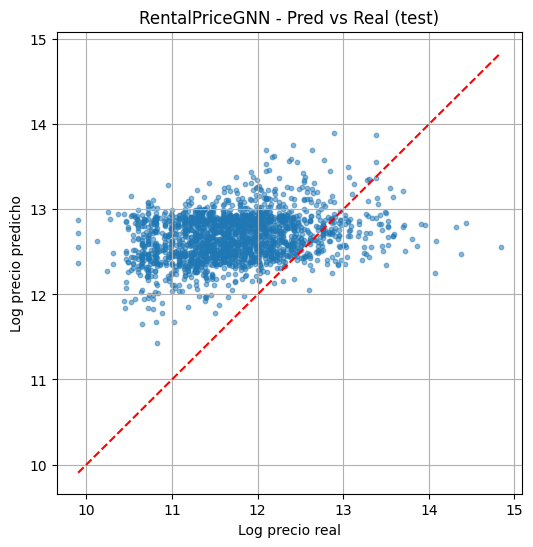

In [7]:
# Gráfico pred vs real (log precio)
plt.figure(figsize=(6,6))
plt.scatter(true_log, pred_log, alpha=0.5, s=10)
lims = [min(true_log.min(), pred_log.min()), max(true_log.max(), pred_log.max())]
plt.plot(lims, lims, 'r--')
plt.xlabel('Log precio real')
plt.ylabel('Log precio predicho')
plt.title('RentalPriceGNN - Pred vs Real (test)')
plt.grid(True)
plt.show()


In [8]:
# Evaluación Inductive: grafo solo con test nodes
test_coords = test_df[['latitud', 'longitud']].values
pred_inductive = model.predict(
    X=test_feats,
    coords=test_coords,
    inductive=True
)
pred_log_ind = pred_inductive
true_log_ind = test_df['log_precio'].to_numpy()

rmse_log_ind = np.sqrt(np.mean((pred_log_ind - true_log_ind) ** 2))
r2_log_ind = 1 - np.sum((pred_log_ind - true_log_ind) ** 2) / np.sum((true_log_ind - true_log_ind.mean()) ** 2)

pred_price_ind = np.exp(pred_log_ind)
true_price_ind = np.exp(true_log_ind)
rmse_price_ind = np.sqrt(np.mean((pred_price_ind - true_price_ind) ** 2))

print("=== Inductive Learning ===")
print(f"RMSE log: {rmse_log_ind:.4f}")
print(f"R2 log:   {r2_log_ind:.4f}")
print(f"RMSE precio (ARS): {rmse_price_ind:,.0f}")

=== Inductive Learning ===
RMSE log: 1.1243
R2 log:   -1.7562
RMSE precio (ARS): 252,975


In [9]:
# Comparación de métricas
print("=== Comparación Transductive vs Inductive ===")
print(f"Transductive - RMSE log: {rmse_log:.4f}, R2 log: {r2_log:.4f}, RMSE precio: {rmse_price:,.0f}")
print(f"Inductive     - RMSE log: {rmse_log_ind:.4f}, R2 log: {r2_log_ind:.4f}, RMSE precio: {rmse_price_ind:,.0f}")

if r2_log > r2_log_ind:
    print("Transductive es mejor (más preciso, pero menos realista).")
elif r2_log_ind > r2_log:
    print("Inductive es mejor (más realista, pero potencialmente menos preciso).")
else:
    print("Ambos tienen rendimiento similar.")

=== Comparación Transductive vs Inductive ===
Transductive - RMSE log: 1.1651, R2 log: -1.9595, RMSE precio: 243,431
Inductive     - RMSE log: 1.1243, R2 log: -1.7562, RMSE precio: 252,975
Inductive es mejor (más realista, pero potencialmente menos preciso).


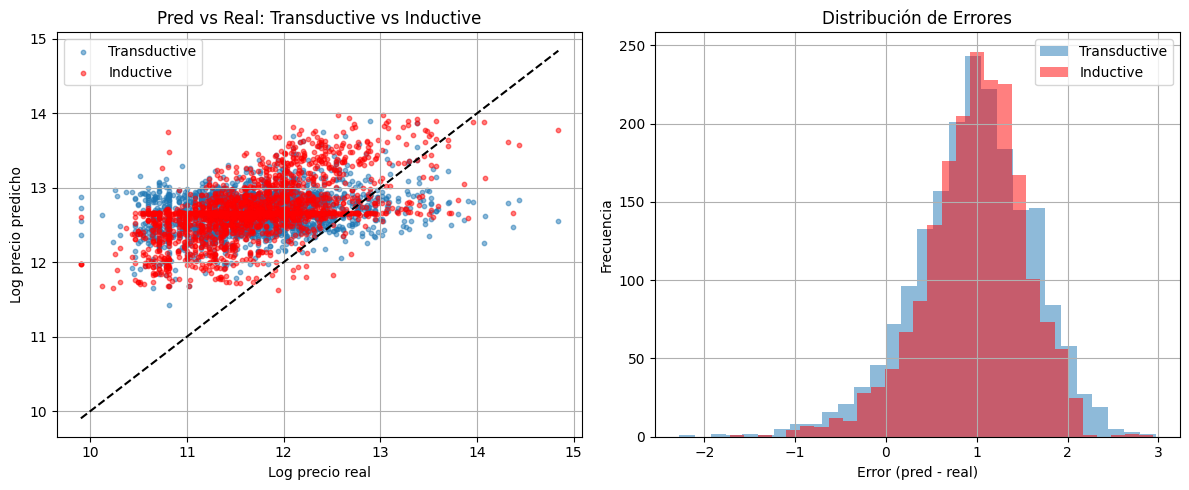

In [10]:
# Gráfico comparativo
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(true_log, pred_log, alpha=0.5, s=10, label='Transductive')
plt.scatter(true_log_ind, pred_log_ind, alpha=0.5, s=10, label='Inductive', color='red')
lims = [min(true_log.min(), pred_log.min(), true_log_ind.min(), pred_log_ind.min()),
        max(true_log.max(), pred_log.max(), true_log_ind.max(), pred_log_ind.max())]
plt.plot(lims, lims, 'k--')
plt.xlabel('Log precio real')
plt.ylabel('Log precio predicho')
plt.title('Pred vs Real: Transductive vs Inductive')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
errors_trans = pred_log - true_log
errors_ind = pred_log_ind - true_log_ind
plt.hist(errors_trans, alpha=0.5, label='Transductive', bins=30)
plt.hist(errors_ind, alpha=0.5, label='Inductive', bins=30, color='red')
plt.xlabel('Error (pred - real)')
plt.ylabel('Frecuencia')
plt.title('Distribución de Errores')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Comparación: Transductive vs Inductive Learning

Comparamos los dos enfoques de predicción:
- **Transductive**: Usa grafo combinado train+test (con conexiones cross-edges).
- **Inductive**: Construye grafo solo con nodos de test (sin conexiones a train).